# 01 — パッケージと制御ループ

## 背景・目的
ROSパッケージ名ではなく、**誰が、何Hzで、どのデータを更新するか**を読む。
コード変更時に「計画」「推定」「実行」「I/O」の責務を混ぜないための章である。

実装対応:
- [`legged_controllers/src/LeggedController.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_controllers/src/LeggedController.cpp)
- [`legged_hw/src/LeggedHWLoop.cpp`](https://github.com/qiayuanliao/legged_control/tree/a7f381c0367e98e31c01336e678eef47e304d40d/legged_hw/src/LeggedHWLoop.cpp)
- `legged_controllers/config/a1/task.info`


In [1]:
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "pyproject.toml").exists():
        ROOT = candidate
        break

np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({"figure.figsize": (9, 4), "axes.grid": True})
print("repository:", ROOT)


repository: /home/takuya/work/mpc_dog


## パッケージの責務

- `legged_controllers`: controller plugin、参照軌道publisher、500 Hz update
- `legged_interface`: OCS2のOCPへコスト・制約・参照を組み込む
- `legged_estimation`: IMU・関節・接地から並進位置/速度を推定
- `legged_wbc`: 現在時刻の全身QP
- `legged_common`: hybrid joint interface
- `legged_hw`, `legged_unitree_hw`, `legged_gazebo`: read/update/write境界
- OCS2（外部）: SQP、centroidal dynamics、GaitScheduleの基盤

`LeggedController::update()` の順序:
1. 状態推定
2. 観測をMPCへ共有
3. 最新policy取得・現在時刻で評価
4. WBC
5. safety check
6. 12関節command


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 25512 (\N{CJK UNIFIED IDEOGRAPH-63A8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 23450 (\N{CJK UNIFIED IDEOGRAPH-5B9A}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12388 (\N{HIRAGANA LETTER TU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:158: UserWarning: Gl

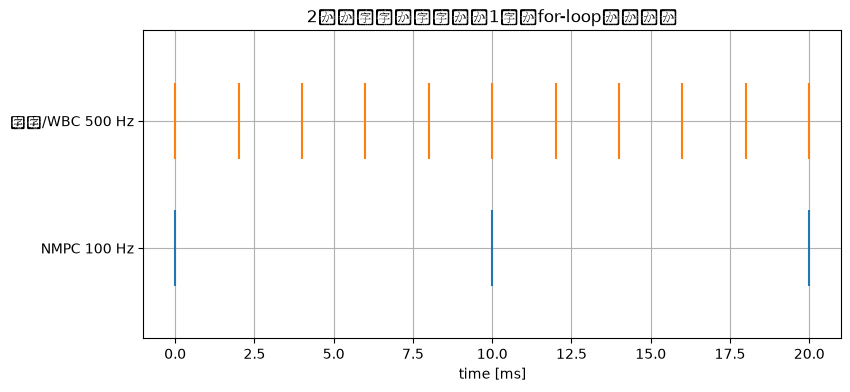

fast updates: 11 slow updates: 3


In [2]:
# 20 msの間に、500 Hzループと100 Hzループがいつ動くか可視化する。
dt_fast, dt_slow, duration = 1/500, 1/100, 0.020
t_fast = np.arange(0, duration + 1e-12, dt_fast)
t_slow = np.arange(0, duration + 1e-12, dt_slow)

fig, ax = plt.subplots()
ax.eventplot([t_fast * 1e3, t_slow * 1e3],
             lineoffsets=[1, 0], linelengths=0.6,
             colors=["tab:orange", "tab:blue"])
ax.set_yticks([0, 1], ["NMPC 100 Hz", "推定/WBC 500 Hz"])
ax.set_xlabel("time [ms]")
ax.set_title("2つの周期は同期した1本のfor-loopではない")
plt.show()

print("fast updates:", len(t_fast), "slow updates:", len(t_slow))


## コードを読む順序
`setupMpc()` → `setupMrt()` → `starting()` → `update()` の順で読む。
`update()`だけを読むと、別threadの `advanceMpc()` と初期policy待ちを見落とす。

実装値は horizon 1.0 s、`sqp.dt=0.015` s、SQP反復1、MPC 100 Hz、
hardware/WBC 500 Hz。予測点数は概算で約67だが、イベント時刻で区間が分割されるため、
常に固定67変数と決めつけない。

### 変更課題
MPCを50 Hzへ下げる前に確認するもの:
solver時間、policy age、500 Hz側の補間、接触切替の遅れ、閉ループ安定性。


## 章固有の背景
                ROS callback、100 Hz solver thread、500 Hz hardware loopが別々に進むため、周期と所有dataを知らずに局所コードだけ読むとraceと遅延を見落とす。

                ## 章固有の目的
                初期化からmotor commandまでをthread境界付きで追い、各周期の責務を変更前に説明できるようにする。

                ## この章のASCIIデータフロー
                ```text
                LeggedHWLoop::update(500 Hz) -> estimate -> evaluate latest policy -> WBC -> write
                         ^                 |
                         | shared observation/policy
                 advanceMpc(100 Hz) <-----+
                ```

                ## 上流C++ / faithful pseudocode と数式の行対応
                ```cpp
                // external/legged_control/legged_controllers/src/LeggedController.cpp
setupMpc();                 // SqpMpcを構築: OCP policy生成器
setupMrt();                 // advanceMpc() threadを開始: 100 Hz
updateStateEstimation(...); // sensor -> x_k
setCurrentObservation(x_k); // 数式の初期条件 x(0)=x_k
evaluatePolicy(t, x_k,...); // (x*(t),u*(t),mode(t))を現在時刻で評価
wbc_->update(...);          // 現在点を42変数QPへ渡す
// external/legged_control/legged_hw/src/LeggedHWLoop.cpp
controllerManager_->update(...); // read -> controller -> write の500 Hz境界
                ```

                **事実のラベル**: `external/legged_control/` の記述はcommit
                `a7f381c0367e98e31c01336e678eef47e304d40d` の上流実装事実。数式展開はそのinterfaceを説明する理論。
                `src/legged_control_mujoco/` に言及した行はproject所有adapterの実装であり、
                ROS1/OCS2 SQP原実装とは同一ではない。

                ## 章固有の結論
                `LeggedController::update` は500 Hzの配線、`MPC_MRT_Interface::advanceMpc` は100 Hzの計画更新である。両者を一つの同期loopとは扱わない。
